In [ ]:
from PipingSystem import PipingSystem
from Elements.Coil import Coil
from Elements.Singularities import SingularityLoss
from Elements.Tube import Tube
import CoolProp.CoolProp as cp
import numpy as np
from Pumps.Lauda import LaudaPumpFit
import matplotlib.pyplot as plt

Definimos serpentin

In [2]:
coil = Coil(d_in = 5.15e-3, d_out=6.35e-3, lenght=1, orientation=-90, material="copper", vueltas = 5, pitch=6.35e-3)

Definimos el sistema

In [ ]:
fluxsys = PipingSystem()
fluxsys.add_tube(Tube(d_in = 9e-3, d_out = 11e-3, lenght=1.5, orientation=0, material="Plastic")) # Primera manguera del lauda
fluxsys.add_singularity_loss(SingularityLoss(0.5)) # Primer cambio de diametro
fluxsys.add_coil(coil) # Serpentin
fluxsys.add_singularity_loss(SingularityLoss(0.5)) # Segundo cambio de diamtro
fluxsys.add_tube(Tube(d_in = 9e-3, d_out = 11e-3, lenght=1.5, orientation=0, material="Plastic")) # Segunda manguera del lauda
fluxsys.conect() # Conectar

Definimos el Fluido

In [5]:
T = 273.15 + 1.0  
P = 101325        
aumento_viscosidad = 1.33
fluido = 'Water'  
rho = cp.PropsSI('D', 'T', T, 'P', P, fluido)
mu = cp.PropsSI('V', 'T', T, 'P', P, fluido) * aumento_viscosidad

Buscamos donde cruza la curva del sistema con la curva de la bomba

In [7]:
fluxsys.cross_system_pump(rho,mu, LaudaPumpFit.Pa4m3s, 3.25e-5,verbose=True);


═════════════════════════════════════════════
       🎯 PUNTO DE OPERACIÓN DEL SISTEMA      
═════════════════════════════════════════════
 🔹 Caudal volumétrico :    1.936 L/min
 🔹 Caudal másico      : 3.23e-05 m³/s
 🔹 Presión de cruce   :  17977.2 Pa
 🔹 Pérdida de altura  :    1.833 m.c.a.
═════════════════════════════════════════════



Buscamos una buena guess inicial

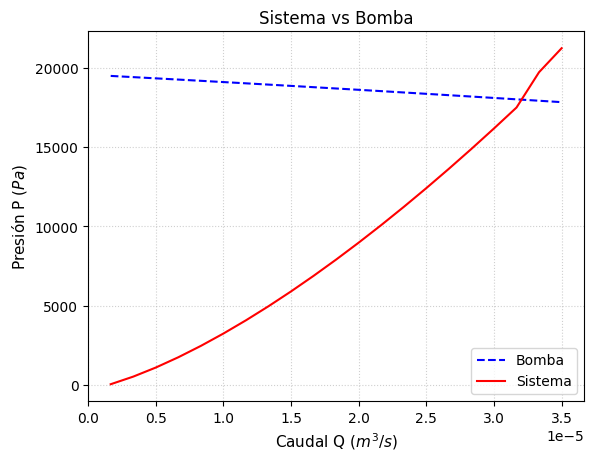

In [10]:
LPM_TO_M3S = 1 / 60000 

Q_test = np.arange(0.1 * LPM_TO_M3S, 15 * LPM_TO_M3S, 0.1 * LPM_TO_M3S)

P_system = np.zeros_like(Q_test)
P_pump = np.zeros_like(Q_test)
last_i = len(Q_test) - 1
for i in range(len(Q_test)):
    dh, dp = fluxsys.get_perdida_altura_closed(Q_test[i], rho, mu)
    P_system[i] = dp
    P_pump[i] = LaudaPumpFit.Pa4m3s(Q_test[i])
    if dp >= 20000:
        last_i = i
        break

Q_plot = Q_test[:last_i+1]
P_system_plot = P_system[:last_i+1]
P_pump_plot = P_pump[:last_i+1]

plt.plot(Q_plot, P_pump_plot, '--', color='blue', label='Bomba')
plt.plot(Q_plot, P_system_plot, '-', color='red', label = "Sistema")

plt.title('Sistema vs Bomba', fontsize=12)
plt.xlabel('Caudal Q ($m^3/s$)', fontsize=11)
plt.ylabel('Presión P ($Pa$)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

